In [36]:
pip install opencv-python numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [37]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:


dataset_path = r"C:\Users\Abhi\Downloads\archive\leapGestRecog"

X = []
y = []

for subject in os.listdir(dataset_path):
    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path):

        for gesture in os.listdir(subject_path):

            gesture_path = os.path.join(subject_path, gesture)

            for image in os.listdir(gesture_path):

                img_path = os.path.join(gesture_path, image)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                img = cv2.resize(img, (64,64))

                X.append(img.flatten())
                y.append(gesture)

print("Images Loaded Successfully")

Images Loaded Successfully


In [39]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(4794, 4096)
(4794,)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [42]:
y_pred = model.predict(X_test)

In [43]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


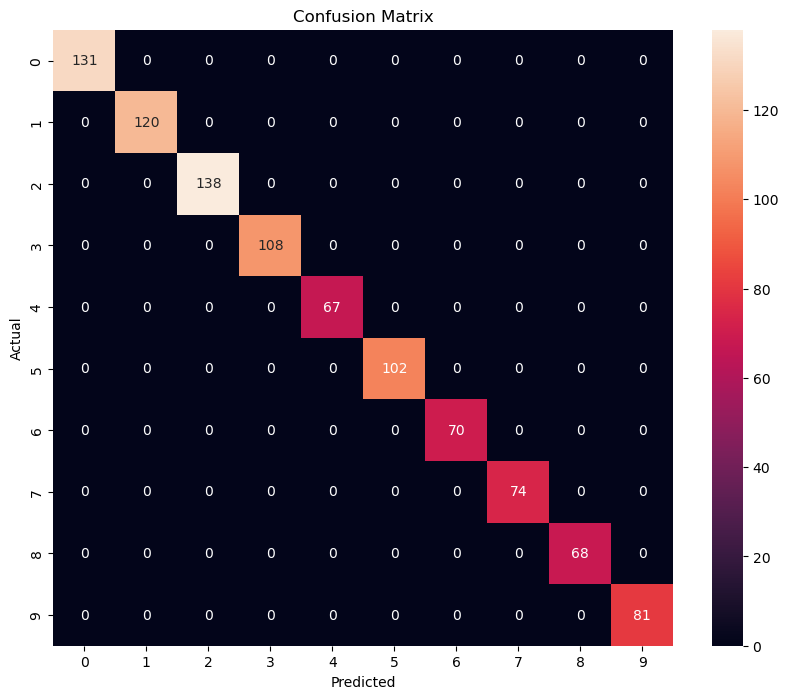

In [44]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       131
         02_l       1.00      1.00      1.00       120
      03_fist       1.00      1.00      1.00       138
04_fist_moved       1.00      1.00      1.00       108
     05_thumb       1.00      1.00      1.00        67
     06_index       1.00      1.00      1.00       102
        07_ok       1.00      1.00      1.00        70
08_palm_moved       1.00      1.00      1.00        74
         09_c       1.00      1.00      1.00        68
      10_down       1.00      1.00      1.00        81

     accuracy                           1.00       959
    macro avg       1.00      1.00      1.00       959
 weighted avg       1.00      1.00      1.00       959



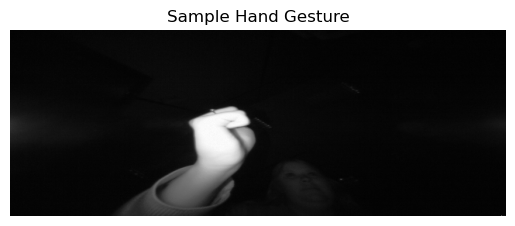

In [46]:
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Sample Hand Gesture")
plt.axis("off")
plt.show()

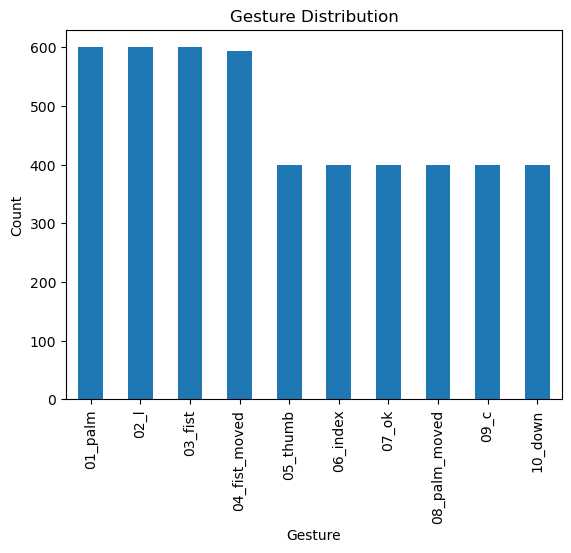

In [47]:
pd.Series(y).value_counts().plot(kind='bar')
plt.title("Gesture Distribution")
plt.xlabel("Gesture")
plt.ylabel("Count")
plt.show()